---

## **Projet Deep Learning**
## **Classification de tissus cancéreux colorectaux**

---


---

**Ce notebook est conçu pour être :**
- **reproductible** (chemins relatifs, seeds fixées)
- **idempotent** (relançable sans retélécharger si les fichiers sont déjà présents)
- **traçable** (quality gates go/no-go explicites)

---


---

# PARTIE 4 : TRANSFER LEARNING — ResNet-18

---


---

### Objectif

Utiliser un modèle pré-entraîné sur ImageNet (ResNet-18) et l'adapter à notre problème de classification de tissus. Le transfer learning exploite les features déjà apprises (contours, textures, formes) sur 1.2 million d'images naturelles, et les réutilise pour nos images médicales.

### Progression du projet
- **Partie 2 (MLP)** : 63.08% test accuracy — chaque pixel traité indépendamment, pas de notion de texture
- **Partie 3 (CNN)** : 92.38% test accuracy — exploitation de la structure spatiale, confusion Cancer/Mucosa résolue
- **Partie 4 (ResNet-18)** : le modèle arrive avec des connaissances visuelles pré-apprises, il devrait faire mieux avec moins d'entraînement

### Consignes du sujet
- Poids ImageNet pré-entraînés
- Gérer le mismatch de taille d'entrée (28×28 → 224×224)
- Seuil : ≥ 85% test accuracy
- Deux expériences : (a) couches gelées (head seul), (b) fine-tuning complet
- **Q4.1** : Test accuracy exacte des deux, différence en points de pourcentage
- **Q4.2** : Conséquence négative du upscaling 8× + alternative
- **Q4.3** : Pourquoi le transfer learning marche (pas parce qu'ImageNet contient des images médicales)

### Rappels techniques (Lab 3)
- ResNet-18 attend des images 224×224 — nos images font 28×28, il faut les agrandir (upscaling 8×)
- Deux modes : frozen (on ne touche que la dernière couche) vs fine-tuning (on entraîne tout)
- La normalisation ImageNet vs PathMNIST sera testée (décision EDA)

### Pourquoi ImageNet comme base de transfer learning :
- C'est le standard en vision par ordinateur — ResNet-18 pré-entraîné est disponible directement dans PyTorch
- Les features de bas niveau (contours, lignes, textures, gradients) sont universelles : elles existent dans toutes les images, qu'elles soient naturelles ou médicales
- Ce n'est **pas** parce qu'ImageNet contient des images médicales (il n'en contient pas — ce sont des chiens, des voitures, des paysages). Le transfer learning fonctionne parce que les patterns visuels fondamentaux sont les mêmes partout
- Il n'existe pas de modèle pré-entraîné sur de l'histologie dans PyTorch standard — utiliser un modèle spécialisé serait hors périmètre du cours

---


---

### Choix d'architecture et d'hyperparamètres ResNet-18 — justifications

**Pourquoi ResNet-18 :**
- Architecture pré-entraînée sur ImageNet (1.2M images, 1000 classes) — les premières couches ont déjà appris à détecter des contours, textures et formes génériques
- 18 couches — assez profond pour être performant, assez léger pour tourner sur notre GPU
- Architecture à connexions résiduelles (skip connections) — résout le problème des gradients qui disparaissent dans les réseaux profonds

**Upscaling 28×28 → 224×224 :**
- ResNet-18 attend des images 224×224 — nos images font 28×28
- On utilise `transforms.Resize((224, 224))` pour agrandir 8×
- Conséquence : les images seront floues (on n'invente pas de détails), mais les features de bas niveau (contours, couleurs) restent exploitables

**Normalisation ImageNet :**
- On utilise les stats ImageNet ([0.485, 0.456, 0.406] / [0.229, 0.224, 0.225]) et non PathMNIST
- Raison : le modèle a été pré-entraîné avec ces stats — ses poids internes sont calibrés pour ces valeurs
- Si on normalisait avec PathMNIST, les activations internes seraient décalées

**Deux expériences (consigne du sujet) :**
- **(a) Frozen** : on gèle toutes les couches sauf la dernière (fc) — le modèle utilise ses features ImageNet telles quelles et n'apprend que le classifieur final
- **(b) Fine-tuning complet** : on dégèle toutes les couches — le modèle adapte ses features à nos images médicales

**Batch size réduit (32) :**
- Les images 224×224 prennent 64× plus de mémoire que les 28×28
- On réduit le batch size pour ne pas saturer la mémoire GPU

**CrossEntropyLoss + Adam (lr=0.001) :**
- Cohérence avec les parties précédentes
- Pour le fine-tuning, un learning rate plus bas pourrait être envisagé pour ne pas détruire les features pré-apprises

---


In [1]:
# Lien avec le notebook 1 (EDA) — imports
# Version 1.0 — 20 mars 2026

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import medmnist
from medmnist import PathMNIST
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
print("Imports OK")


Imports OK


In [2]:
# Versions — traçabilité
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")


Python   : 3.12.10
PyTorch  : 2.10.0+cu128
MedMNIST : 3.0.2
NumPy    : 2.4.3


In [3]:
# Reproductibilité complète (CPU + GPU + cuDNN)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")


Device        : cuda
cuDNN determ. : True


In [4]:
# Constantes et dataset — calculées dans l'EDA (notebook 1)
DATA_DIR = os.path.join(".", "data")
NORM_MEAN = [0.7405, 0.5330, 0.7058]
NORM_STD  = [0.1237, 0.1768, 0.1244]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
N_CLASSES = 9

# Recharger le dataset
train_dataset = PathMNIST(split='train', download=False, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=False, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=False, root=DATA_DIR)

info = train_dataset.info
labels_names = info['label']
CLASS_NAMES = list(labels_names.values())

# Timer global du notebook
notebook_start_time = time.time()

print(f"NORM_MEAN    : {NORM_MEAN}")
print(f"NORM_STD     : {NORM_STD}")
print(f"IMAGENET_MEAN: {IMAGENET_MEAN}")
print(f"IMAGENET_STD : {IMAGENET_STD}")
print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
print("✓ Lien avec notebook 1 établi")


NORM_MEAN    : [0.7405, 0.533, 0.7058]
NORM_STD     : [0.1237, 0.1768, 0.1244]
IMAGENET_MEAN: [0.485, 0.456, 0.406]
IMAGENET_STD : [0.229, 0.224, 0.225]
Train : 89996 | Val : 10004 | Test : 7180
✓ Lien avec notebook 1 établi


In [5]:
# Fonction d'entraînement — réutilisée depuis le notebook 2
# Même fonction pour tous les modèles (MLP, CNN, ResNet, ViT)

def train_model(model, train_loader, val_loader, epochs=50, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        'loss': [], 'accuracy': [],
        'val_loss': [], 'val_accuracy': []
    }

    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for images, labels_batch in train_loader:
            images = images.to(device)
            labels_batch = labels_batch.squeeze().long().to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels_batch).sum().item()
            train_total += images.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels_batch in val_loader:
                images = images.to(device)
                labels_batch = labels_batch.squeeze().long().to(device)

                outputs = model(images)
                loss = criterion(outputs, labels_batch)

                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels_batch).sum().item()
                val_total += images.size(0)

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        history['loss'].append(epoch_train_loss)
        history['accuracy'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1:>3}/{epochs} | "
              f"Train loss: {epoch_train_loss:.6f} acc: {epoch_train_acc:.6f} | "
              f"Val loss: {epoch_val_loss:.6f} acc: {epoch_val_acc:.6f}"
              f"{' <- best' if epoch + 1 == best_epoch else ''}")

    model.load_state_dict(best_model_state)
    print(f"\n✓ Meilleur modèle restauré (époque {best_epoch}, val_loss: {best_val_loss:.6f})")

    return history

print("✓ Fonction train_model chargée")


✓ Fonction train_model chargée


In [6]:
# Preprocessing ResNet-18 — upscaling 28×28 → 224×224
# ResNet-18 a été entraîné sur ImageNet en 224×224, il attend cette taille
# On utilise les stats ImageNet car le modèle a été pré-entraîné avec

resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),                      # upscaling 8× (28→224)
    transforms.ToTensor(),                              # uint8 → float32 [0,1]
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)   # stats ImageNet
])

# Charger les datasets avec le transform ResNet
train_resnet = PathMNIST(split='train', transform=resnet_transform, download=False, root=DATA_DIR)
val_resnet   = PathMNIST(split='val',   transform=resnet_transform, download=False, root=DATA_DIR)
test_resnet  = PathMNIST(split='test',  transform=resnet_transform, download=False, root=DATA_DIR)

# DataLoaders — batch size réduit car les images 224×224 prennent plus de mémoire GPU
BATCH_SIZE_RESNET = 32
train_loader_resnet = DataLoader(train_resnet, batch_size=BATCH_SIZE_RESNET, shuffle=True)
val_loader_resnet   = DataLoader(val_resnet,   batch_size=BATCH_SIZE_RESNET, shuffle=False)
test_loader_resnet  = DataLoader(test_resnet,  batch_size=BATCH_SIZE_RESNET, shuffle=False)

# Vérification
sample_img, sample_label = train_resnet[0]
assert sample_img.shape == (3, 224, 224), f"Shape attendue (3,224,224), obtenue {sample_img.shape}"
print(f"Image ResNet : shape={sample_img.shape}, dtype={sample_img.dtype}")
print(f"  Min={sample_img.min():.4f}, Max={sample_img.max():.4f}")
print(f"DataLoaders ResNet créés (batch_size={BATCH_SIZE_RESNET})")
print(f"  Train : {len(train_loader_resnet)} batches")
print(f"  Val   : {len(val_loader_resnet)} batches")
print(f"  Test  : {len(test_loader_resnet)} batches")
print("✓ Preprocessing ResNet terminé")


Image ResNet : shape=torch.Size([3, 224, 224]), dtype=torch.float32
  Min=0.8880, Max=2.1694
DataLoaders ResNet créés (batch_size=32)
  Train : 2813 batches
  Val   : 313 batches
  Test  : 225 batches
✓ Preprocessing ResNet terminé


In [7]:
# Expérience (a) — ResNet-18 frozen : on ne touche que la dernière couche
# Toutes les couches convolutives sont gelées — on réutilise les features ImageNet telles quelles

def create_resnet_frozen(n_classes=9):
    # Charger ResNet-18 pré-entraîné sur ImageNet
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Geler toutes les couches — aucun gradient ne sera calculé
    for param in model.parameters():
        param.requires_grad = False
    
    # Remplacer la dernière couche (fc) : 512 → 9 classes au lieu de 1000
    # Cette couche n'est PAS gelée — c'est la seule qu'on entraîne
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    
    return model

# Créer et vérifier
torch.manual_seed(SEED)
resnet_frozen = create_resnet_frozen()
resnet_frozen = resnet_frozen.to(device)

total_params = sum(p.numel() for p in resnet_frozen.parameters())
trainable_params = sum(p.numel() for p in resnet_frozen.parameters() if p.requires_grad)
print(f"ResNet-18 frozen :")
print(f"  Paramètres totaux      : {total_params:,}")
print(f"  Paramètres entraînables : {trainable_params:,} (dernière couche uniquement)")
print(f"  Paramètres gelés       : {total_params - trainable_params:,}")
print("✓ ResNet-18 frozen créé")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\xiabi/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s] 


ResNet-18 frozen :
  Paramètres totaux      : 11,181,129
  Paramètres entraînables : 4,617 (dernière couche uniquement)
  Paramètres gelés       : 11,176,512
✓ ResNet-18 frozen créé


In [9]:
# Entraînement ResNet-18 frozen — 20 époques
# Moins d'époques car seule la dernière couche est entraînée → convergence rapide
start_time = time.time()
print("=== Entraînement ResNet-18 FROZEN (20 époques) ===")
print(f"Entraînement sur {device}...")
history_frozen = train_model(resnet_frozen, train_loader_resnet, val_loader_resnet, epochs=20, learning_rate=0.001)
train_time_frozen = time.time() - start_time

print(f"\nTemps d'entraînement : {train_time_frozen:.1f}s ({train_time_frozen/60:.1f} min)")


=== Entraînement ResNet-18 FROZEN (20 époques) ===
Entraînement sur cuda...
Epoch   1/20 | Train loss: 0.370275 acc: 0.867105 | Val loss: 0.313810 acc: 0.891044 <- best
Epoch   2/20 | Train loss: 0.363594 acc: 0.870905 | Val loss: 0.281670 acc: 0.899340 <- best
Epoch   3/20 | Train loss: 0.356330 acc: 0.872817 | Val loss: 0.312973 acc: 0.885646
Epoch   4/20 | Train loss: 0.354282 acc: 0.873983 | Val loss: 0.284311 acc: 0.899940
Epoch   5/20 | Train loss: 0.352149 acc: 0.875372 | Val loss: 0.282619 acc: 0.900540
Epoch   6/20 | Train loss: 0.349241 acc: 0.875372 | Val loss: 0.297349 acc: 0.898840
Epoch   7/20 | Train loss: 0.348358 acc: 0.874983 | Val loss: 0.295848 acc: 0.897141
Epoch   8/20 | Train loss: 0.348088 acc: 0.876872 | Val loss: 0.309256 acc: 0.891843
Epoch   9/20 | Train loss: 0.343485 acc: 0.878872 | Val loss: 0.306881 acc: 0.891343
Epoch  10/20 | Train loss: 0.346642 acc: 0.877195 | Val loss: 0.296600 acc: 0.894642
Epoch  11/20 | Train loss: 0.344707 acc: 0.876906 | Val lo

In [10]:
# Évaluation ResNet-18 frozen sur le test set
resnet_frozen.eval()
test_correct, test_total = 0, 0
all_preds_frozen = []
all_labels_frozen = []

with torch.no_grad():
    for images, labels_batch in test_loader_resnet:
        images = images.to(device)
        labels_batch = labels_batch.squeeze().long().to(device)
        
        outputs = resnet_frozen(images)
        preds = outputs.argmax(1)
        
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        
        all_preds_frozen.extend(preds.cpu().numpy())
        all_labels_frozen.extend(labels_batch.cpu().numpy())

test_accuracy_frozen = test_correct / test_total

print("=== Résultats ResNet-18 FROZEN (test set) ===")
print(f"  Test accuracy : {test_accuracy_frozen:.6f}")
print(f"  Seuil requis : >= 85% -> {'✓ ATTEINT' if test_accuracy_frozen >= 0.85 else '✗ NON ATTEINT'}")


=== Résultats ResNet-18 FROZEN (test set) ===
  Test accuracy : 0.869916
  Seuil requis : >= 85% -> ✓ ATTEINT


In [ ]:
# Matrice de confusion ResNet-18 frozen
cm_frozen = confusion_matrix(all_labels_frozen, all_preds_frozen)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_frozen, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Prédit')
ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — ResNet-18 FROZEN (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

cm_frozen_off = cm_frozen.copy()
np.fill_diagonal(cm_frozen_off, 0)
max_idx = np.unravel_index(cm_frozen_off.argmax(), cm_frozen_off.shape)
max_count = cm_frozen_off[max_idx]
print(f"
Plus grande confusion frozen : {max_count} images de '{CLASS_NAMES[max_idx[0]]}' classées comme '{CLASS_NAMES[max_idx[1]]}'")


---

### Résultats ResNet-18 frozen (head seul)

**Test accuracy : 0.869916 (86.99%)** — seuil de 85% atteint. Le modèle utilise les features ImageNet telles quelles et n'apprend que le classifieur final (dernière couche linéaire, ~4 600 paramètres entraînables sur 11.1M).

Le frozen converge vite (best epoch 20, val 90.1%) mais plafonne : les features ImageNet (apprises sur des photos naturelles) ne sont pas optimales pour distinguer les textures subtiles de l'histologie H&E.

---


In [ ]:
# Classification report — frozen
print("\n=== Classification report ResNet-18 FROZEN (test set) ===")
print(classification_report(all_labels_frozen, all_preds_frozen, target_names=CLASS_NAMES, digits=4))


In [11]:
# Expérience (b) — ResNet-18 fine-tuning complet : on dégèle toutes les couches
def create_resnet_finetune(n_classes=9):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Toutes les couches sont entraînables (pas de gel)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

resnet_finetune = create_resnet_finetune()
resnet_finetune = resnet_finetune.to(device)

total_params = sum(p.numel() for p in resnet_finetune.parameters())
trainable_params = sum(p.numel() for p in resnet_finetune.parameters() if p.requires_grad)
print(f"ResNet-18 fine-tuning :")
print(f"  Paramètres totaux       : {total_params:,}")
print(f"  Paramètres entraînables : {trainable_params:,} (toutes les couches)")
print("✓ ResNet-18 fine-tuning créé")


ResNet-18 fine-tuning :
  Paramètres totaux       : 11,181,129
  Paramètres entraînables : 11,181,129 (toutes les couches)
✓ ResNet-18 fine-tuning créé


In [12]:
# Entraînement ResNet-18 fine-tuning — 20 époques
start_time = time.time()
print("=== Entraînement ResNet-18 FINE-TUNING (20 époques) ===")
print(f"Entraînement sur {device}...")
history_finetune = train_model(resnet_finetune, train_loader_resnet, val_loader_resnet, epochs=20, learning_rate=0.0001)
train_time_finetune = time.time() - start_time

print(f"\nTemps d'entraînement : {train_time_finetune:.1f}s ({train_time_finetune/60:.1f} min)")


=== Entraînement ResNet-18 FINE-TUNING (20 époques) ===
Entraînement sur cuda...
Epoch   1/20 | Train loss: 0.160991 acc: 0.946253 | Val loss: 0.068121 acc: 0.978009 <- best
Epoch   2/20 | Train loss: 0.068507 acc: 0.976566 | Val loss: 0.049644 acc: 0.984506 <- best
Epoch   3/20 | Train loss: 0.046072 acc: 0.984588 | Val loss: 0.046878 acc: 0.985306 <- best
Epoch   4/20 | Train loss: 0.033591 acc: 0.988611 | Val loss: 0.037695 acc: 0.988605 <- best
Epoch   5/20 | Train loss: 0.028749 acc: 0.990144 | Val loss: 0.030851 acc: 0.989104 <- best
Epoch   6/20 | Train loss: 0.021554 acc: 0.992889 | Val loss: 0.041276 acc: 0.987505
Epoch   7/20 | Train loss: 0.019869 acc: 0.993444 | Val loss: 0.045331 acc: 0.985506
Epoch   8/20 | Train loss: 0.016502 acc: 0.994500 | Val loss: 0.042499 acc: 0.986905
Epoch   9/20 | Train loss: 0.016384 acc: 0.994800 | Val loss: 0.043556 acc: 0.986006
Epoch  10/20 | Train loss: 0.013193 acc: 0.995478 | Val loss: 0.052416 acc: 0.984906
Epoch  11/20 | Train loss: 0.

In [13]:
# Évaluation ResNet-18 fine-tuning sur le test set
resnet_finetune.eval()
test_correct, test_total = 0, 0
all_preds_ft = []
all_labels_ft = []

with torch.no_grad():
    for images, labels_batch in test_loader_resnet:
        images = images.to(device)
        labels_batch = labels_batch.squeeze().long().to(device)
        
        outputs = resnet_finetune(images)
        preds = outputs.argmax(1)
        
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        
        all_preds_ft.extend(preds.cpu().numpy())
        all_labels_ft.extend(labels_batch.cpu().numpy())

test_accuracy_ft = test_correct / test_total

print("=== Q4.1 — Résultats ResNet-18 (test set) ===")
print(f"  Frozen       : {test_accuracy_frozen:.6f}")
print(f"  Fine-tuning  : {test_accuracy_ft:.6f}")
print(f"  Différence   : {(test_accuracy_ft - test_accuracy_frozen)*100:+.2f} pts")
print(f"  Seuil requis : >= 85% -> {'✓ ATTEINT' if test_accuracy_ft >= 0.85 else '✗ NON ATTEINT'}")


=== Q4.1 — Résultats ResNet-18 (test set) ===
  Frozen       : 0.869916
  Fine-tuning  : 0.915320
  Différence   : +4.54 pts
  Seuil requis : >= 85% -> ✓ ATTEINT


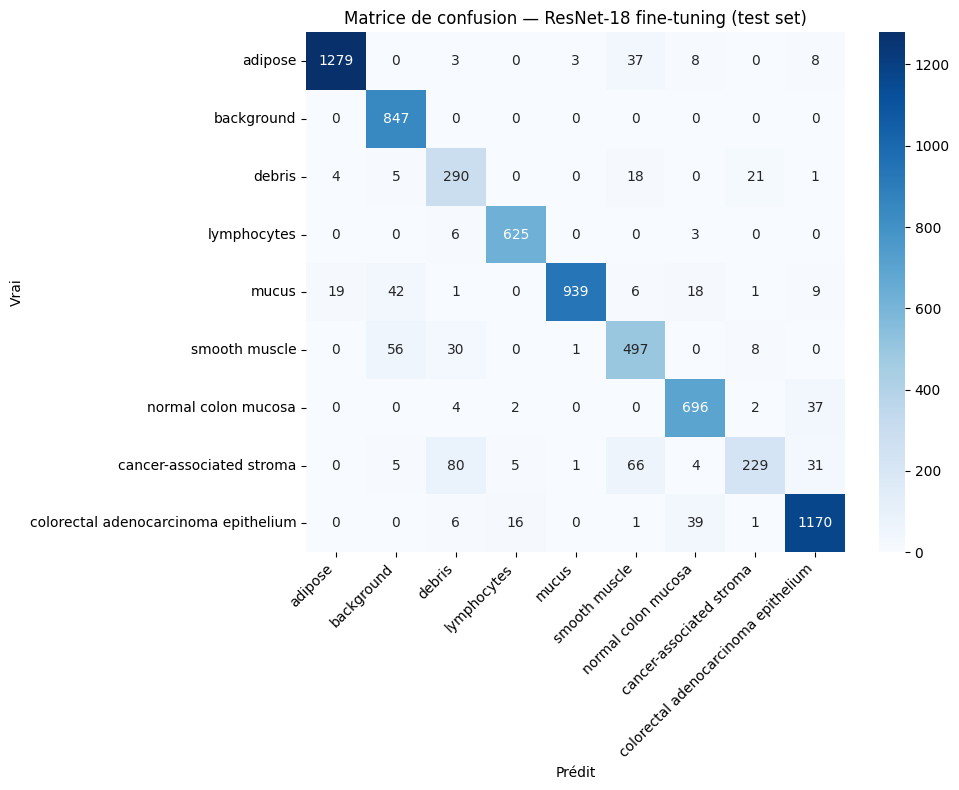


Plus grande confusion : 80 images de 'cancer-associated stroma' classées comme 'debris'

=== Classification report (test set) ===
                                      precision    recall  f1-score   support

                             adipose     0.9823    0.9559    0.9689      1338
                          background     0.8869    1.0000    0.9401       847
                              debris     0.6905    0.8555    0.7642       339
                         lymphocytes     0.9645    0.9858    0.9750       634
                               mucus     0.9947    0.9072    0.9490      1035
                       smooth muscle     0.7952    0.8395    0.8168       592
                 normal colon mucosa     0.9062    0.9393    0.9225       741
            cancer-associated stroma     0.8740    0.5439    0.6706       421
colorectal adenocarcinoma epithelium     0.9315    0.9489    0.9401      1233

                            accuracy                         0.9153      7180
         

In [14]:
# Matrice de confusion + classification report — fine-tuning
cm_ft = confusion_matrix(all_labels_ft, all_preds_ft)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Prédit')
ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — ResNet-18 fine-tuning (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

cm_ft_off = cm_ft.copy()
np.fill_diagonal(cm_ft_off, 0)
max_idx = np.unravel_index(cm_ft_off.argmax(), cm_ft_off.shape)
max_count = cm_ft_off[max_idx]
print(f"\nPlus grande confusion : {max_count} images de '{CLASS_NAMES[max_idx[0]]}' classées comme '{CLASS_NAMES[max_idx[1]]}'")

print("\n=== Classification report (test set) ===")
print(classification_report(all_labels_ft, all_preds_ft, target_names=CLASS_NAMES, digits=4))


---

### Résultats ResNet-18 fine-tuning

**Test accuracy : 0.915320 (91.53%)** — +4.54 pts par rapport au frozen. Le fine-tuning adapte toutes les couches aux spécificités de l'histologie H&E.

**Plus grande confusion : 80 images de stroma classées comme debris** — même pattern que le CNN. Le stroma (F1=0.67) reste la classe la plus difficile, quel que soit le modèle.

**Comparaison avec le CNN from scratch (92.38%) :** le ResNet fine-tuning (91.53%) fait légèrement moins bien malgré 40× plus de paramètres (11.1M vs ~280K) et des poids pré-entraînés. L'upscaling 8× des images 28→224 est probablement responsable de cette sous-performance.

---


---

### Q4.1 — Résultats frozen vs fine-tuning

| Expérience | Test accuracy | Val accuracy (best) | Temps | Paramètres entraînables |
|-----------|--------------|--------------------|----|----------------------|
| Frozen (head seul) | 0.869916 (86.99%) | 0.901240 (90.12%) | 34.3 min | ~4 600 (dernière couche) |
| Fine-tuning complet | 0.915320 (91.53%) | 0.993303 (99.33%) | 65.5 min | 11 181 129 (toutes) |
| **Différence** | **+4.54 pts** | **+9.21 pts** | **+31.2 min** | |

Le fine-tuning est nettement meilleur : en adaptant toutes les couches aux images d'histologie H&E, le modèle apprend des features spécifiques (textures de tissus, densité cellulaire) que les features ImageNet seules ne captent pas. Le frozen plafonne car les features ImageNet (chiens, voitures, paysages) ne sont pas optimales pour distinguer stroma de debris.

---


---

### Q4.2 — Conséquence négative de l'upscaling 8×

Nos images de 28×28 sont agrandies à 224×224 par interpolation bilinéaire. Cet upscaling 8× ne crée aucun détail — il étire les 784 pixels d'origine sur 50 176 pixels. Le résultat est flou.

**Impact mesuré :** le ResNet fine-tuning (91.53%) ne dépasse pas notre CNN from scratch (92.38%) malgré 11.1M de paramètres contre ~280K et des poids pré-entraînés sur 1.2M d'images. L'explication la plus probable est que le flou de l'upscaling détruit les textures fines que le CNN exploite directement sur les images 28×28 natives.

**La preuve :** le stroma (F1=0.67) et les debris (F1=0.76) restent les classes les plus faibles — exactement les classes qui dépendent de textures subtiles, les plus affectées par le flou.

**Alternative :** MedMNIST fournit PathMNIST en résolutions 64×64, 128×128 et 224×224 (voir les URL dans les métadonnées de l'EDA). Utiliser la version 224×224 native éviterait l'upscaling et donnerait au ResNet des images nettes à sa résolution d'origine.

---


---

### Q4.3 — Pourquoi le transfer learning fonctionne

Ce n'est **pas** parce qu'ImageNet contient des images médicales — ImageNet c'est 1.2M de photos de chiens, voitures, paysages, nourriture. Aucune image d'histologie.

Le transfer learning fonctionne parce que les premières couches d'un CNN apprennent des features **universelles** :
- Contours, lignes, gradients de couleur → existent dans toutes les images, médicales ou pas
- Textures, motifs répétitifs → utiles pour distinguer les types de tissus

**La preuve dans nos résultats :** le frozen (86.99%) montre que les features ImageNet seules, sans aucune adaptation, classifient déjà 87% des tissus correctement. Ces features génériques (contours, textures) sont directement applicables à l'histologie.

Le fine-tuning (91.53%) améliore de +4.54 pts en adaptant les couches profondes aux spécificités H&E : les tons violets de l'hématoxyline, les structures glandulaires de la muqueuse, la densité cellulaire du cancer. Ces features-là ne sont pas dans ImageNet — le modèle les apprend pendant le fine-tuning.

---


---

## Bilan Partie 4 — Transfer Learning ResNet-18

### Résultats

| Métrique | Frozen | Fine-tuning | CNN (rappel) | MLP (rappel) |
|----------|--------|-------------|-------------|--------------|
| Test accuracy | 86.99% | 91.53% | 92.38% | 63.08% |
| Val accuracy (best) | 90.12% | 99.33% | 98.7% | ~70% |
| Nb paramètres | 11.1M (4.6K entraînables) | 11.1M | ~280K | 1.37M |
| Temps entraînement | 34.3 min | 65.5 min | 8.9 min | ~2 min |
| Pire F1 | — | Stroma (0.67) | Stroma (0.63) | Debris (0.42) |

### Ce qu'on a appris

1. **Le transfer learning fonctionne** — même des features de photos naturelles sont utiles pour l'histologie
2. **Le fine-tuning est indispensable** — le frozen seul (+4.54 pts de différence) ne suffit pas pour les classes difficiles
3. **L'upscaling 8× est le facteur limitant** — le ResNet ne dépasse pas le CNN malgré 40× plus de paramètres
4. **Le stroma reste la classe la plus difficile** — quel que soit le modèle (CNN, ResNet), F1 autour de 0.63-0.67

### Ce qu'on attend de la partie 5 (ViT)

- Le ViT part de zéro (pas de pré-entraînement) — il devra tout apprendre
- Avec 90K images, il pourrait sous-performer par rapport au CNN (les Transformers ont besoin de beaucoup de données)
- Mais sa vision globale (attention sur tous les patches) pourrait aider sur les classes où le contexte spatial compte

---


In [15]:
# Sauvegarde des résultats ResNet-18
torch.save(resnet_finetune.state_dict(), os.path.join(DATA_DIR, 'resnet_finetune_model.pth'))
torch.save(resnet_frozen.state_dict(), os.path.join(DATA_DIR, 'resnet_frozen_model.pth'))

resnet_results = {
    'model_name': 'ResNet-18',
    'test_accuracy_frozen': test_accuracy_frozen,
    'test_accuracy_finetune': test_accuracy_ft,
    'train_time_frozen': train_time_frozen,
    'train_time_finetune': train_time_finetune,
    'n_params': sum(p.numel() for p in resnet_finetune.parameters()),
}

print(f"Modèles sauvegardés")
print(f"  Frozen test acc     : {test_accuracy_frozen:.6f}")
print(f"  Fine-tuning test acc: {test_accuracy_ft:.6f}")
print(f"  Nb paramètres       : {resnet_results['n_params']:,}")
print("✓ Sauvegarde terminée")


Modèles sauvegardés
  Frozen test acc     : 0.869916
  Fine-tuning test acc: 0.915320
  Nb paramètres       : 11,181,129
✓ Sauvegarde terminée


In [16]:
# Temps total d'exécution du notebook
notebook_total_time = time.time() - notebook_start_time
print(f"Temps total du notebook : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")


Temps total du notebook : 10239.7s (170.7 min)
